In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report,
                              mean_squared_error, r2_score)

Mounted at /content/drive


In [ ]:
cancer_file_path = '/content/drive/My Drive/IntroToML/Cancer.csv'
cancer_df = pd.read_csv(cancer_file_path)
cancer_df = cancer_df.drop(columns=['id'])
cancer_df = cancer_df.loc[:, ~cancer_df.columns.str.contains('^Unnamed')]
cancer_df['diagnosis'] = cancer_df['diagnosis'].map({'M': 1, 'B': 0})

X_cancer = cancer_df.drop(columns=['diagnosis']).values
y_cancer = cancer_df['diagnosis'].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
X_cancer, y_cancer, test_size=0.2, random_state=0, stratify=y_cancer)

sc_cancer = StandardScaler()
X_train_c = sc_cancer.fit_transform(X_train_c)
X_test_c = sc_cancer.transform(X_test_c)

print(f'Training rows: {len(y_train_c)}, Test rows: {len(y_test_c)}')

Training rows: 455, Test rows: 114


In [ ]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
svm_results = {}
svm_models = {}

for kernel in kernels:
    svc = SVC(kernel=kernel, class_weight='balanced')
    svc.fit(X_train_c, y_train_c)
    y_pred = svc.predict(X_test_c)

    svm_models[kernel] = svc
    svm_results[kernel] = {
        'accuracy': accuracy_score(y_test_c, y_pred),
        'precision': precision_score(y_test_c, y_pred),
        'recall': recall_score(y_test_c, y_pred),
        'f1': f1_score(y_test_c, y_pred)
    }
    print(f"{kernel:<8} accuracy={svm_results[kernel]['accuracy']:.4f}  "
          f"precision={svm_results[kernel]['precision']:.4f}  "
          f"recall={svm_results[kernel]['recall']:.4f}  "
          f"f1={svm_results[kernel]['f1']:.4f}")

linear   accuracy=0.9298  precision=0.9250  recall=0.8810  f1=0.9024
rbf      accuracy=0.9474  precision=0.9091  recall=0.9524  f1=0.9302
poly     accuracy=0.9474  precision=1.0000  recall=0.8571  f1=0.9231
sigmoid  accuracy=0.9123  precision=0.8636  recall=0.9048  f1=0.8837


         accuracy  precision    recall        f1
linear   0.929825   0.925000  0.880952  0.902439
rbf      0.947368   0.909091  0.952381  0.930233
poly     0.947368   1.000000  0.857143  0.923077
sigmoid  0.912281   0.863636  0.904762  0.883721


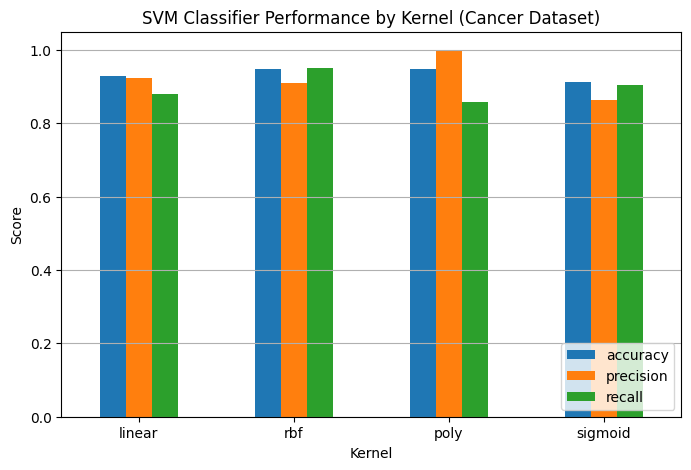

In [ ]:
results_df = pd.DataFrame(svm_results).T
print(results_df)

results_df[['accuracy', 'precision', 'recall']].plot(kind='bar', figsize=(8, 5))
plt.title('SVM Classifier Performance by Kernel (Cancer Dataset)')
plt.ylabel('Score')
plt.xlabel('Kernel')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.grid(True, axis='y')
plt.legend(loc='lower right')
plt.show()

Best kernel by test accuracy: rbf
              precision    recall  f1-score   support

      Benign       0.97      0.94      0.96        72
   Malignant       0.91      0.95      0.93        42

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



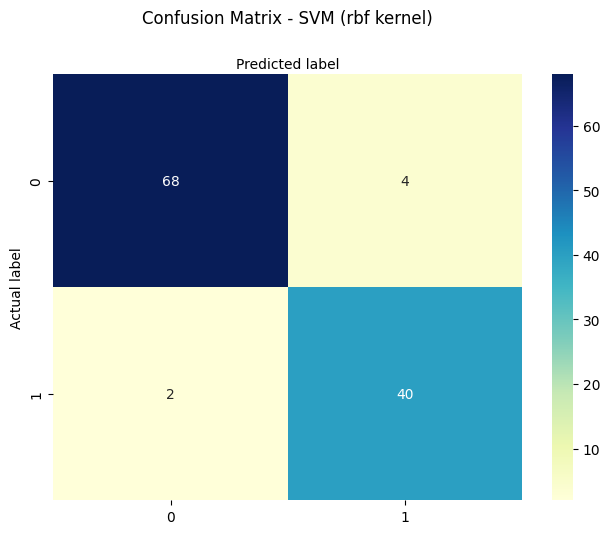

In [ ]:
best_kernel = max(svm_results, key=lambda k: svm_results[k]['accuracy'])
print('Best kernel by test accuracy:', best_kernel)

best_svc = svm_models[best_kernel]
y_pred_best = best_svc.predict(X_test_c)

print(classification_report(y_test_c, y_pred_best, target_names=['Benign', 'Malignant']))

cm = confusion_matrix(y_test_c, y_pred_best)
fig, ax = plt.subplots()
sns.heatmap(pd.DataFrame(cm), annot=True, cmap='YlGnBu', fmt='g')
ax.xaxis.set_label_position('top')
plt.tight_layout()
plt.title(f'Confusion Matrix - SVM ({best_kernel} kernel)', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [ ]:
housing_file_path = '/content/drive/My Drive/IntroToML/Housing.csv'
housing_df = pd.read_csv(housing_file_path)

binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']
housing_df[binary_cols] = housing_df[binary_cols].apply(lambda col: col.map({'yes': 1, 'no': 0}))

features_svr = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
                'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']

X_housing = housing_df[features_svr].values.astype(float)
y_housing = housing_df['price'].values.astype(float)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42)

sc_X = StandardScaler().fit(X_train_h)
X_train_hs = sc_X.transform(X_train_h)
X_test_hs = sc_X.transform(X_test_h)
sc_y = StandardScaler().fit(y_train_h.reshape(-1, 1))
y_train_hs = sc_y.transform(y_train_h.reshape(-1, 1)).ravel()

print(f'Training rows: {len(y_train_h)}, Test rows: {len(y_test_h)}')

Training rows: 436, Test rows: 109


In [ ]:
svr_kernels = {
    'linear': SVR(kernel='linear', C=100),
    'rbf': SVR(kernel='rbf', C=100, gamma=0.1),
    'poly': SVR(kernel='poly', C=100, degree=2)
}

svr_results = {}
svr_predictions = {}

for name, svr in svr_kernels.items():
    svr.fit(X_train_hs, y_train_hs)
    pred_scaled = svr.predict(X_test_hs)
    pred = sc_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()

    svr_predictions[name] = pred
    svr_results[name] = {
        'MSE': mean_squared_error(y_test_h, pred),
        'R2': r2_score(y_test_h, pred)
    }
    print(f"{name:<8} MSE={svr_results[name]['MSE']:.4e}  R2={svr_results[name]['R2']:.4f}")

linear   MSE=1.9311e+12  R2=0.6180
rbf      MSE=2.1957e+12  R2=0.5656
poly     MSE=2.4909e+12  R2=0.5072


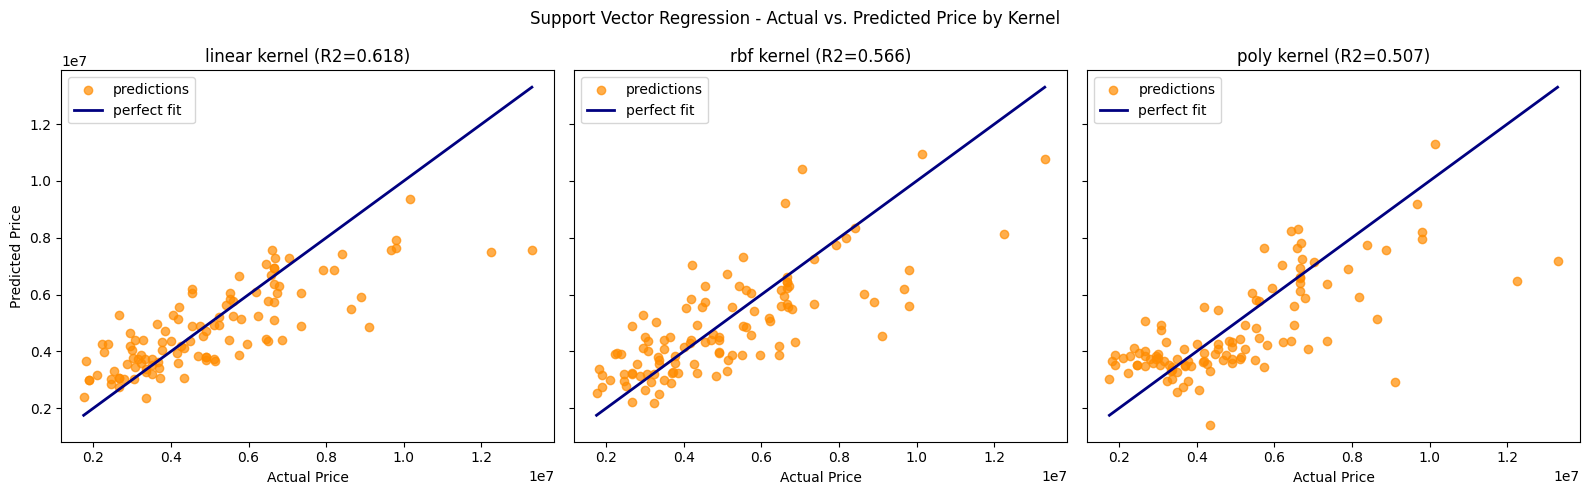

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
min_price, max_price = y_test_h.min(), y_test_h.max()

for ax, (name, pred) in zip(axes, svr_predictions.items()):
    ax.scatter(y_test_h, pred, color='darkorange', alpha=0.7, label='predictions')
    ax.plot([min_price, max_price], [min_price, max_price], color='navy', lw=2, label='perfect fit')
    ax.set_xlabel('Actual Price')
    ax.set_title(f'{name} kernel (R2={svr_results[name]["R2"]:.3f})')
    ax.legend()

axes[0].set_ylabel('Predicted Price')
fig.suptitle('Support Vector Regression - Actual vs. Predicted Price by Kernel')
plt.tight_layout()
plt.show()

                 MSE        R2
linear  1.931070e+12  0.617956
rbf     2.195663e+12  0.565608
poly    2.490866e+12  0.507205


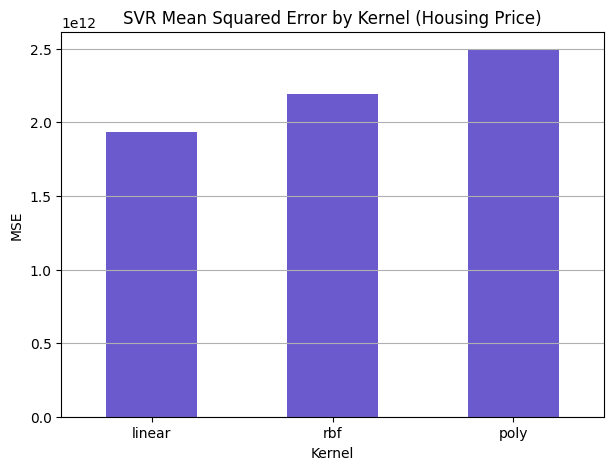

In [ ]:
svr_results_df = pd.DataFrame(svr_results).T
print(svr_results_df)

svr_results_df['MSE'].plot(kind='bar', figsize=(7, 5), color='slateblue')
plt.title('SVR Mean Squared Error by Kernel (Housing Price)')
plt.ylabel('MSE')
plt.xlabel('Kernel')
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.show()